In [1]:
%load_ext autoreload
%autoreload 2

In [1]:
from typing import Iterable

import MeCab
import pandas as pd
from matplotlib import pyplot as plt
import japanize_matplotlib  # 日本語を図で表示するのに必要
import seaborn as sns

In [2]:
import my_classes as cl  # 自作の関数とクラス

In [3]:
default_tokenizer = cl.Tokenizer()
tokenizer = cl.Tokenizer(dic='dict/kokoro_utf8.dic')

In [4]:
kokoro = pd.read_csv('./data/textmining/kokoro.tsv', sep='\t')

In [5]:
kokoro.iloc[:2, ]

,part_id,section_id,paragraph_id,content
0,1,1,1,私はその人を常に先生と呼んでいた。だからここでもただ先生と書くだけで本名は打ち明けない。これ...
1,1,1,2,私が先生と知り合いになったのは鎌倉である。その時私はまだ若々しい書生であった。暑中休暇を利用...


Text(0.5, 1.0, 'Histogram of paragraph length')

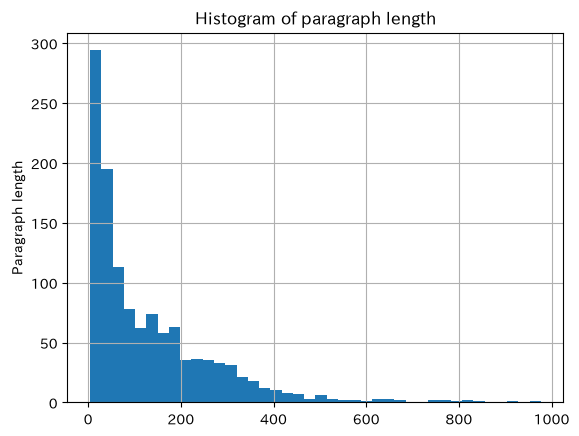

In [6]:
kokoro['content'].str.len().hist(bins=40)
plt.ylabel('Paragraph length')
plt.title('Histogram of paragraph length')

Text(0, 0.5, 'Length')

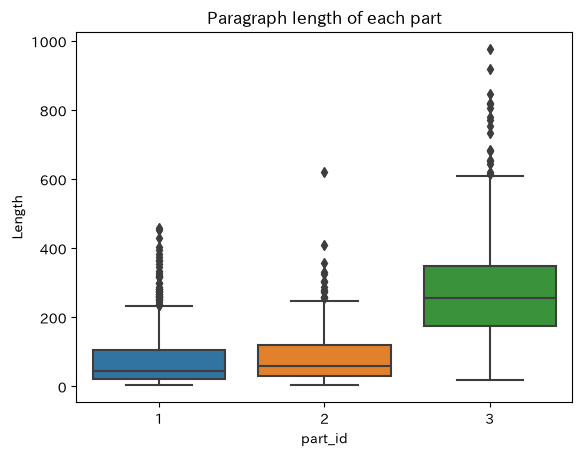

In [7]:
sns.boxplot(x=kokoro['part_id'], y=kokoro['content'].str.len())
plt.title('Paragraph length of each part')
plt.ylabel('Length')

Text(0, 0.5, 'Length')

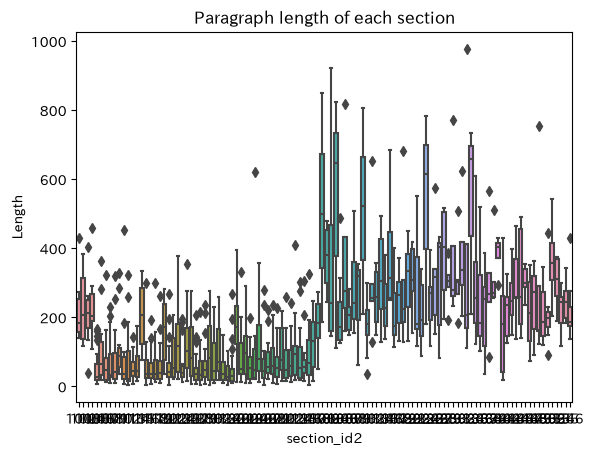

In [8]:
kokoro['section_id2'] = kokoro['part_id'] * 100 + kokoro['section_id']
sns.boxplot(x=kokoro['section_id2'], y=kokoro['content'].str.len())
plt.title('Paragraph length of each section')
plt.ylabel('Length')

# tickを省略

In [9]:
parts = kokoro.groupby('part_id')['content'].agg(''.join).reset_index()

In [10]:
parts['content'].str.len()

0    49137
1    25177
2    85670
Name: content, dtype: int64

In [11]:
count_noun = tokenizer.count_tokens_df(parts['content'], ['名詞'])

In [12]:
count_noun_default = default_tokenizer.count_tokens_df(parts['content'], ['名詞'])

In [13]:
# Kが３回しか出てこない
count_noun_default

,0,1,2
あい,0,1,0
あか,1,0,0
あからさま,0,1,0
あくび,1,0,0
あすこ,3,0,0
...,...,...,...
黙然,0,1,0
鼓動,2,0,1
鼓膜,0,0,1
鼻,0,0,3


In [14]:
count_noun

,0,1,2
あい,0,1,0
あか,1,0,0
あからさま,0,1,0
あくび,1,0,0
あすこ,3,0,0
...,...,...,...
黙然,0,1,0
鼓動,2,0,1
鼓膜,0,0,1
鼻,0,0,3


In [15]:
freq_noun = count_noun.sum(axis=1)

In [18]:
freq_noun.sort_values()

あい         1
鳴り         1
おいど        1
おしまい       1
おのれ        1
        ... 
よう       503
事        575
先生       595
の       1481
私       2693
Length: 3543, dtype: int64

Text(0, 0.5, 'Frequency')

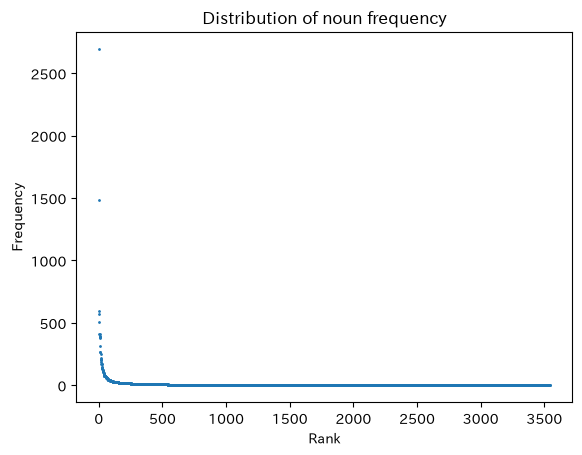

In [16]:
plt.scatter(range(len(freq_noun)), freq_noun.sort_values(ascending=False).values, s=1)
plt.title('Distribution of noun frequency')
plt.xlabel('Rank')
plt.ylabel('Frequency')

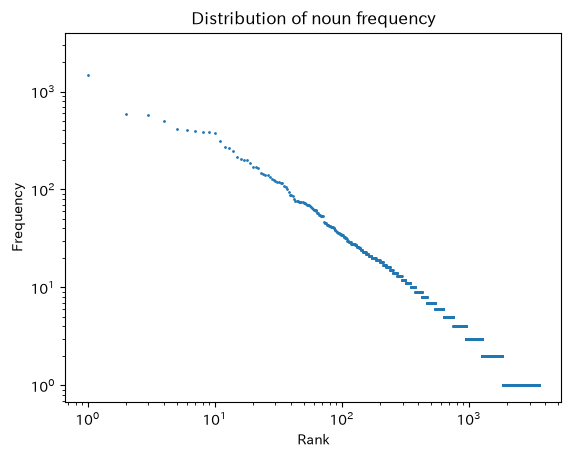

In [17]:
plt.scatter(range(len(freq_noun)), freq_noun.sort_values(ascending=False).values, s=1)
plt.title('Distribution of noun frequency')
plt.xlabel('Rank')
plt.ylabel('Frequency')
plt.xscale('log')
plt.yscale('log')

<Axes: >

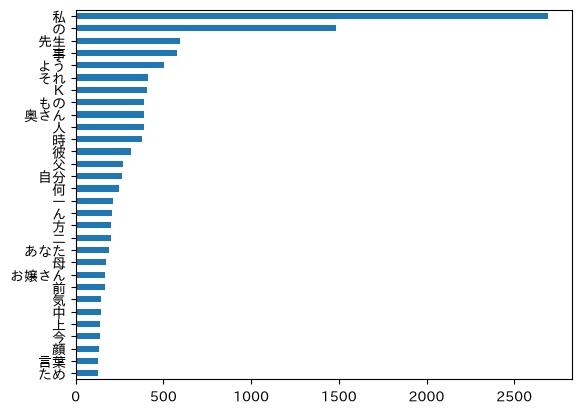

In [18]:
freq_noun.sort_values().tail(30).plot(kind='barh')

Text(0, 0.5, 'Frequency')

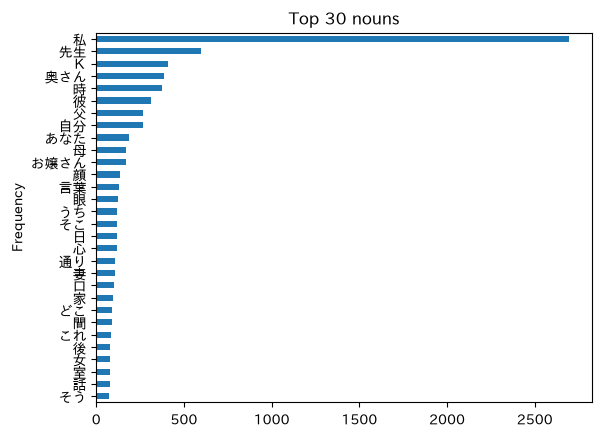

In [19]:
stopwords = set(['事','の','よう','それ','もの', '人', '何','一', 'ん','方','二','前','気','中','上','今','ため'])

freq_noun[[x not in stopwords for x in freq_noun.index]].sort_values().tail(30).plot(kind='barh')
plt.title('Top 30 nouns')
plt.ylabel('Frequency')

Text(0, 0.5, 'Frequency')

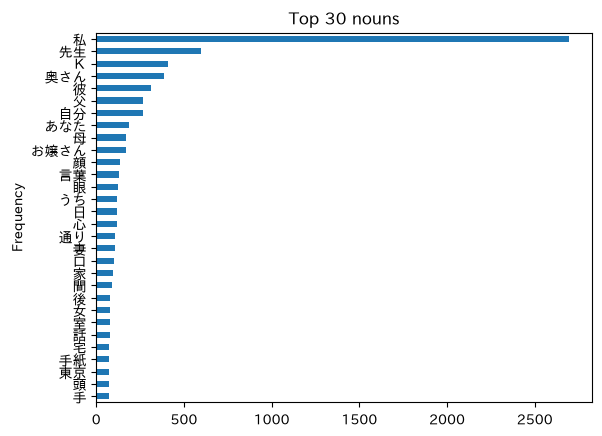

In [20]:
stopwords = set(['事','の','よう','それ','もの', '人', '何','一', 'ん','方','二','前','気','中','上','今','ため', '時', 'そこ', 'どこ', 'これ', 'そう'])

freq_noun[[x not in stopwords for x in freq_noun.index]].sort_values().tail(30).plot(kind='barh')
plt.title('Top 30 nouns')
plt.ylabel('Frequency')

In [21]:
from copy import deepcopy

In [26]:
mat = deepcopy(count_noun)
mat = mat[mat.sum(axis=1) > 50]  # 頻度が50より大きい単語を使う
mat = mat[[x not in stopwords for x in mat.index]]
mat.columns = ['第一部', '第二部', '第三部']

In [27]:
mat

,第一部,第二部,第三部
あなた,70,10,107
うち,43,29,46
お嬢さん,0,0,168
ところ,16,13,39
三,23,9,33
人間,32,9,30
兄,2,57,3
先,20,6,27
先生,509,85,1
卒業,18,32,8


In [28]:
mat_t = mat.T

In [29]:
(mat / mat_t.sum(axis=1)).T

,あなた,うち,お嬢さん,ところ,三,人間,兄,先,先生,卒業,...,私,自分,言葉,話,返事,通り,間,頭,顔,Ｋ
第一部,0.027844,0.017104,0.000000,0.006364,0.009149,0.012729,0.000796,0.007955,0.202466,0.007160,...,0.302705,0.019093,0.017104,0.005569,0.005569,0.008751,0.013922,0.009547,0.016309,0.000000
第二部,0.007225,0.020954,0.000000,0.009393,0.006503,0.006503,0.041185,0.004335,0.061416,0.023121,...,0.257225,0.029624,0.019509,0.006503,0.013006,0.012283,0.008671,0.008671,0.015173,0.000000
第三部,0.022805,0.009804,0.035806,0.008312,0.007033,0.006394,0.000639,0.005754,0.000213,0.001705,...,0.335891,0.037298,0.012148,0.011296,0.004476,0.014706,0.008525,0.007886,0.015558,0.086957


In [30]:
data = (mat / mat_t.sum(axis=1)).T

(<Figure size 800x800 with 1 Axes>,
 <Axes: title={'center': 'PCA Biplot'}, xlabel='PC1 (54.8%)', ylabel='PC2 (45.2%)'>,
 PCA(n_components=2))

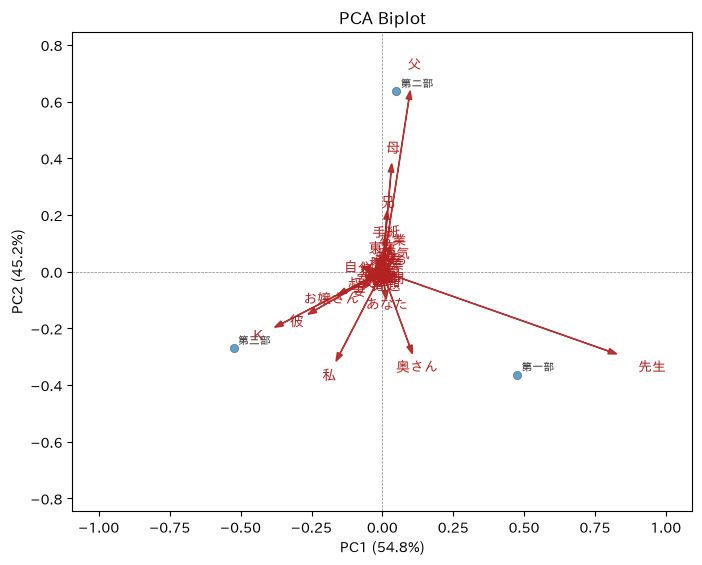

In [31]:
cl.pca_biplot(data, scale=False, annotate_points=True)

In [32]:
ratio = mat / mat.sum(axis=0)
ratio_t = ratio.T

In [33]:
ratio

,第一部,第二部,第三部
あなた,0.027844,0.007225,0.022805
うち,0.017104,0.020954,0.009804
お嬢さん,0.000000,0.000000,0.035806
ところ,0.006364,0.009393,0.008312
三,0.009149,0.006503,0.007033
人間,0.012729,0.006503,0.006394
兄,0.000796,0.041185,0.000639
先,0.007955,0.004335,0.005754
先生,0.202466,0.061416,0.000213
卒業,0.007160,0.023121,0.001705


In [35]:
(ratio_t / ratio.sum(axis=1)).T

,第一部,第二部,第三部
あなた,0.481113,0.124847,0.394040
うち,0.357366,0.437796,0.204838
お嬢さん,0.000000,0.000000,1.000000
ところ,0.264417,0.390248,0.345335
三,0.403298,0.286662,0.310041
人間,0.496721,0.253767,0.249512
兄,0.018666,0.966332,0.015002
先,0.440863,0.240245,0.318893
先生,0.766640,0.232553,0.000807
卒業,0.223843,0.722852,0.053305


(<Figure size 800x800 with 1 Axes>,
 <Axes: title={'center': 'PCA Biplot'}, xlabel='PC1 (71.5%)', ylabel='PC2 (28.5%)'>,
 PCA(n_components=2))

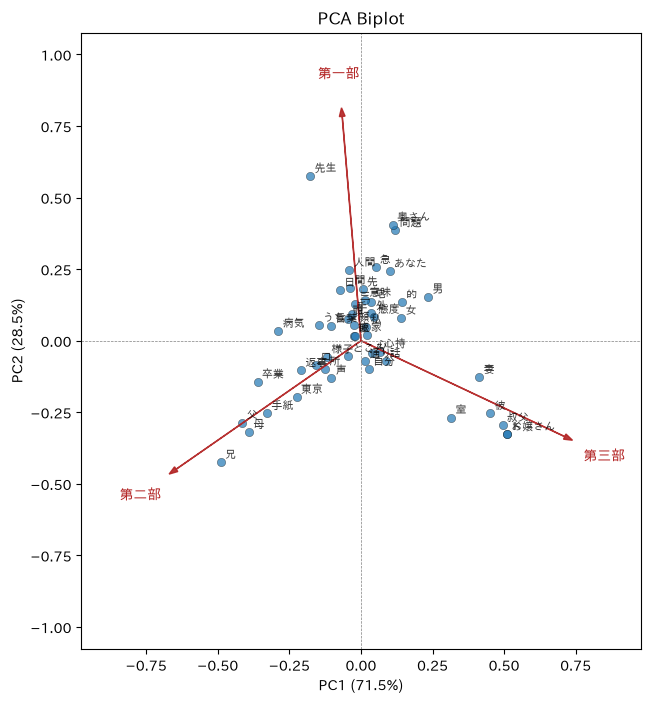

In [34]:
cl.pca_biplot((ratio_t / ratio.sum(axis=1)).T, scale=False, annotate_points=True)

In [35]:
tokenized = parts['content'].apply(tokenizer.tokenize)

In [36]:
default_tokenizer = cl.Tokenizer()
tokenizer = cl.Tokenizer(dic='dict/kokoro_utf8.dic')

In [37]:
bigram = tokenizer.count_bigrams_df(parts['content'], pos=['名詞'])
bigram['freq'] = bigram.sum(axis=1)

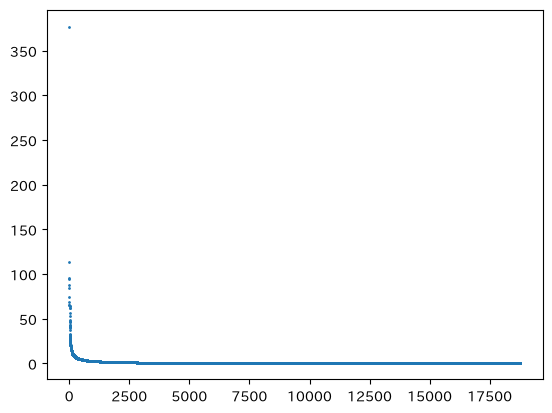

In [38]:
plt.scatter(range(len(bigram)), bigram['freq'].sort_values(ascending=False).values, s=1)

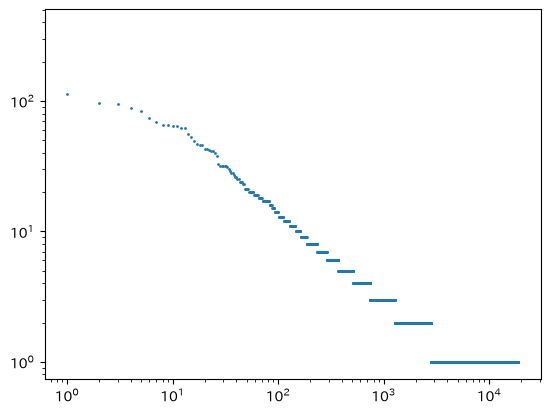

In [39]:
plt.scatter(range(len(bigram)), bigram['freq'].sort_values(ascending=False).values, s=1)
plt.xscale('log')
plt.yscale('log')

In [40]:
import networkx as nx  # ネットワーク分析描画ようライブラリ
import igraph as ig  # igraphの見た目にできる

In [41]:
bigram.shape

(18769, 4)

In [46]:
net = pd.DataFrame([
    (i[0], i[1], x['freq']) for i, x in bigram.iterrows()
    ])
net.columns = 'N1', 'N2', 'freq'
net = net[net['freq'] > 10]

In [47]:
net.head()

,N1,N2,freq
114,あなた,私,19
323,うち,私,14
499,お嬢さん,私,26
773,これ,私,17
950,そう,私,13


In [44]:
net.shape

(146, 3)

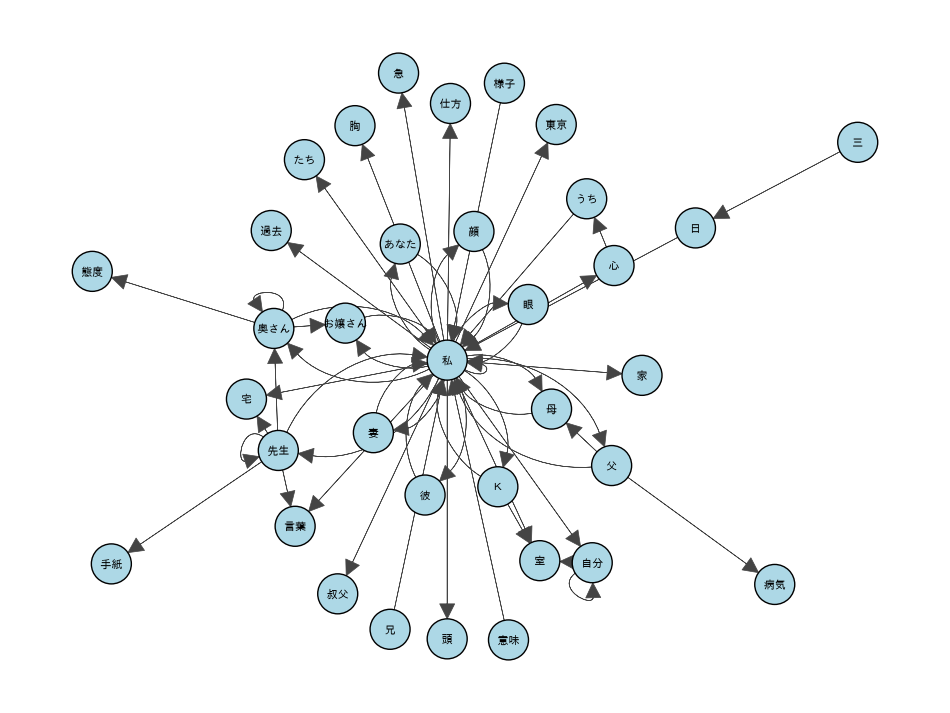

In [48]:
G = nx.DiGraph()
for i, x in net.iterrows():
    if x['N1'] in stopwords or x['N2'] in stopwords:
        continue
    G.add_edge(x['N1'], x['N2'], weight=x['freq'])

fig, ax = plt.subplots(figsize=(12, 9))
g = ig.Graph.from_networkx(G)
g.vs["label"] = [str(x) for x in g.vs["_nx_name"]]
layout = g.layout_fruchterman_reingold(niter=500)

ig.plot(
    g,
    target=ax,
    layout=layout,
    vertex_size=40,
    vertex_color="lightblue",
    vertex_label_size=8,
    vertex_label_color="black",
    edge_width=0.5,
)

In [49]:
# 関数を定義
def plot_graph(net, stopwords, digraph=True):
    if digraph:
        G = nx.DiGraph()
    else:
        G = nx.Graph()
            
    for i, x in net.iterrows():
        if x['N1'] in stopwords or x['N2'] in stopwords:
            continue
        G.add_edge(x['N1'], x['N2'], weight=x['freq'])

    fig, ax = plt.subplots(figsize=(12, 9))
    g = ig.Graph.from_networkx(G)
    g.vs["label"] = [str(x) for x in g.vs["_nx_name"]]
    layout = g.layout_fruchterman_reingold(niter=500)

    ig.plot(
        g,
        target=ax,
        layout=layout,
        vertex_size=40,
        vertex_color="lightblue",
        vertex_label_size=8,
        vertex_label_color="black",
        edge_width=0.5,
    )

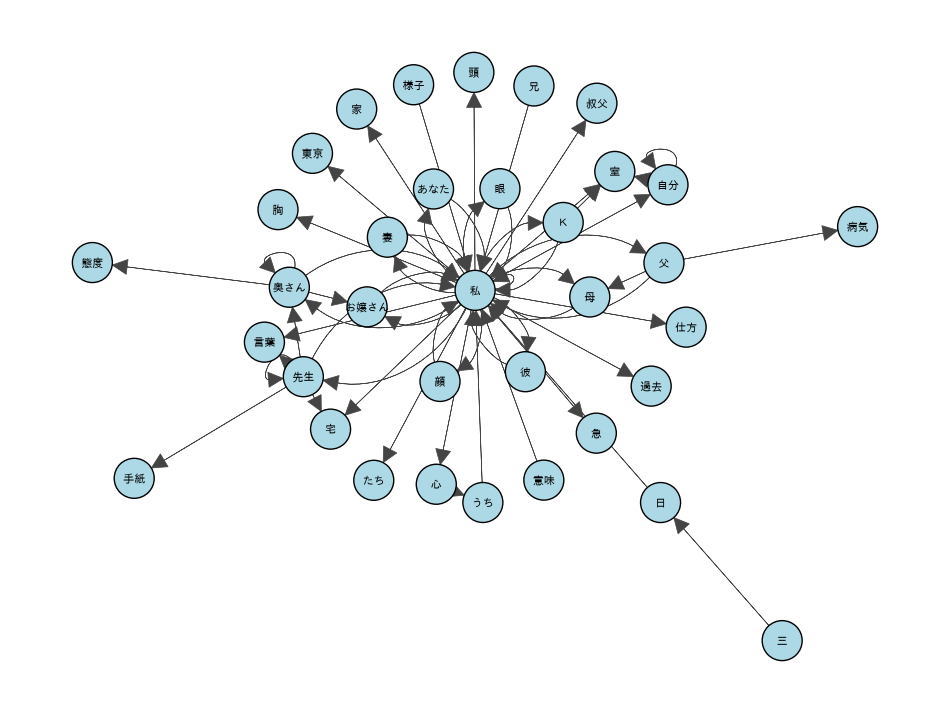

In [199]:
plot_graph(selected, stopwords)

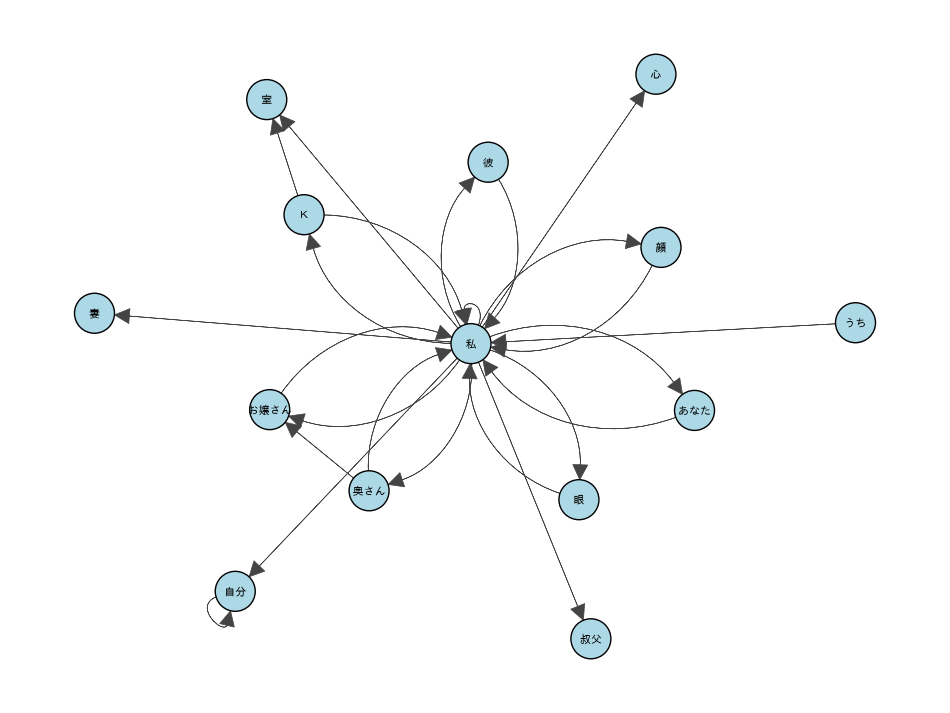

In [103]:
# 第三部
net = pd.DataFrame([
    (i[0], i[1], x[2]) for i, x in bigram.iterrows()
    ])
net.columns = 'N1', 'N2', 'freq'
net = net[net['freq'] > 10]
plot_graph(net, stopwords)

In [65]:
bigram = tokenizer.count_bigrams_df(parts['content'], pos=['名詞', '動詞', '形容詞', '副詞'])
bigram['freq'] = bigram.sum(axis=1)

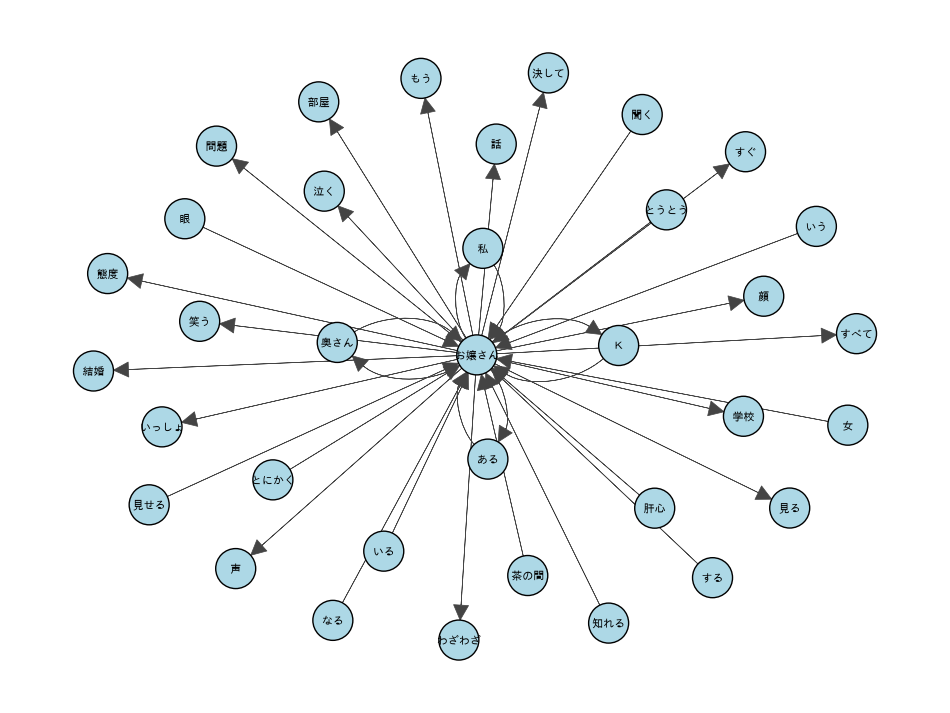

In [66]:
net = pd.DataFrame([
    (i[0], i[1], x[2]) for i, x in bigram.iterrows()
    if (i[0] == 'お嬢さん') or (i[1] == 'お嬢さん')
    ])
net.columns = 'N1', 'N2', 'freq'
net = net[net['freq'] > 1]
plot_graph(net, stopwords)

In [67]:
stopwords = set(['事','の','よう','それ','もの', '人', '何','一', 'ん','方','二','前','気','中','上','今','ため', '時', 'そこ', 'どこ', 'これ', 'そう',
               'いる', 'なる', 'する', 'いう', 'ある'])

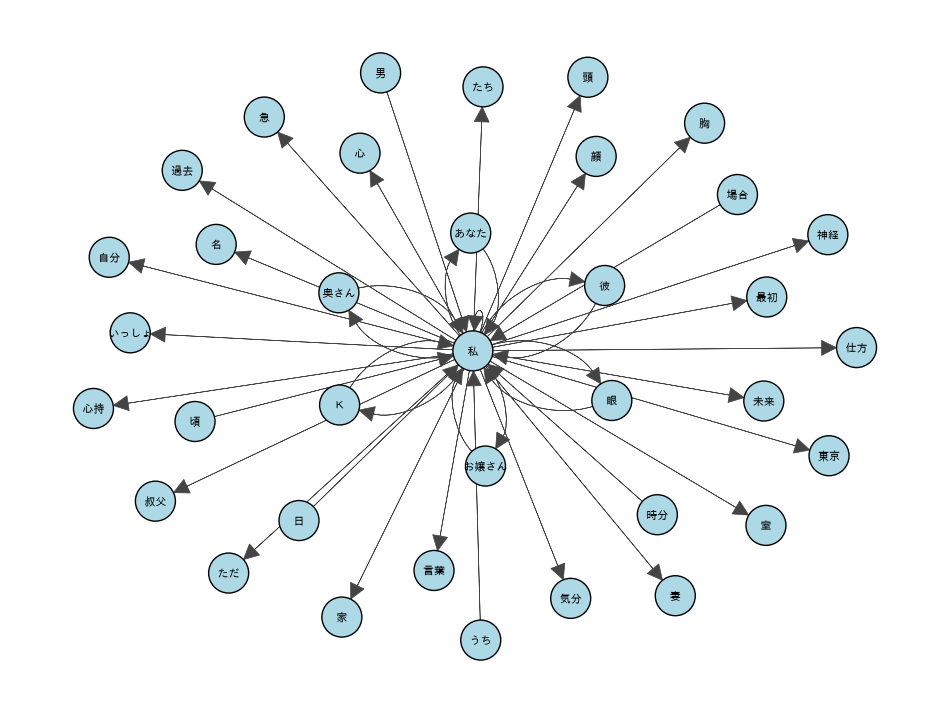

In [68]:
net = pd.DataFrame([
    (i[0], i[1], x[2]) for i, x in bigram.iterrows()
    if ((i[0] == '私') or (i[1] == '私')) and (i[2] == '名詞-名詞')
    ])
net.columns = 'N1', 'N2', 'freq'
net = net[net['freq'] > 4]
plot_graph(net, stopwords)

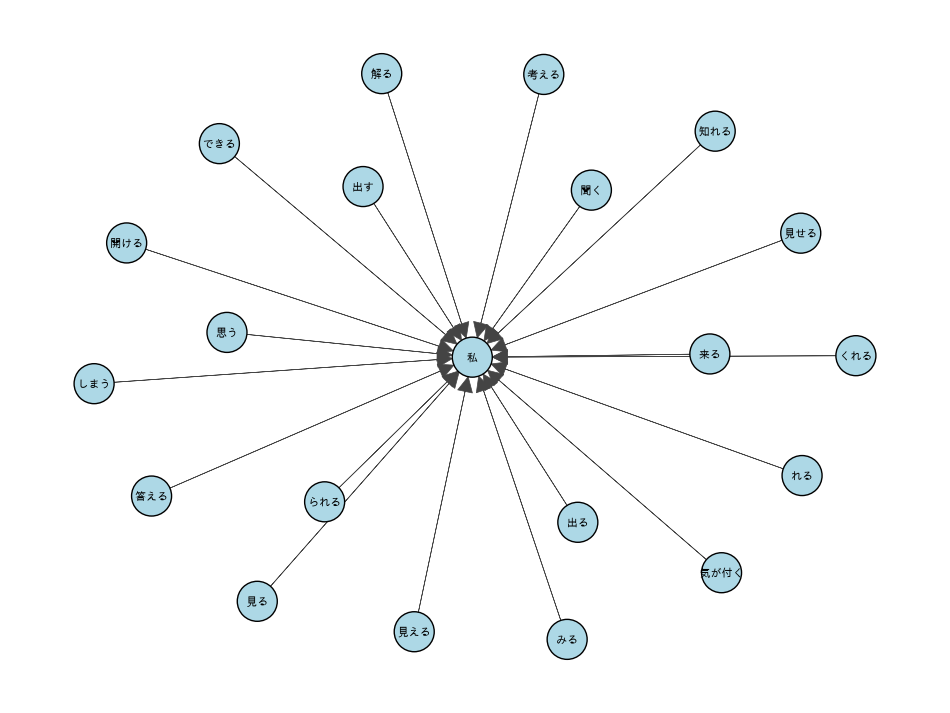

In [69]:
net = pd.DataFrame([
    (i[0], i[1], x[2]) for i, x in bigram.iterrows()
    if ((i[0] == '私') or (i[1] == '私')) and (i[2].startswith('動詞'))
    ])
net.columns = 'N1', 'N2', 'freq'
net = net[net['freq'] > 4]
plot_graph(net, stopwords)

In [70]:
import re  # 正規表現

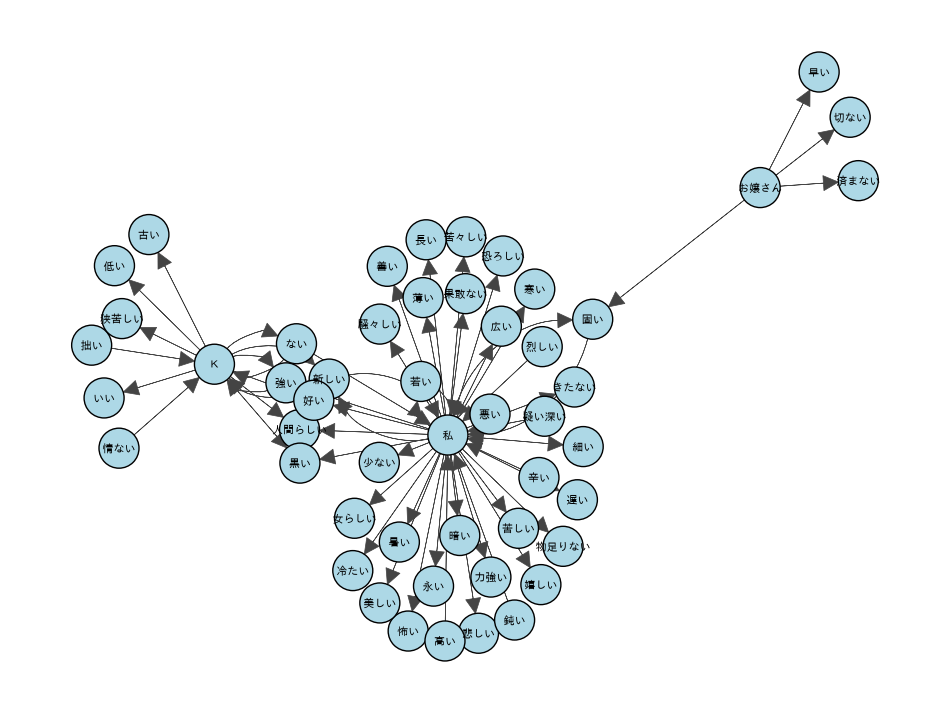

In [72]:
targets = set(['私', 'Ｋ','お嬢さん'])



net = pd.DataFrame([
    (i[0], i[1], x[2]) for i, x in bigram.iterrows()
    if ((i[0] in targets) or (i[1] in targets)) and (re.search('形容', i[2]))
    ])
net.columns = 'N1', 'N2', 'freq'
net = net[net['freq'] > 0]
plot_graph(net, stopwords)

In [73]:
### Bag of wordsを用いた共起関係の分析
## sentenceごとに共起を集計するため、sentenceごとに分けたデータを読み込む

# 加工済みのもの
kokoro_sentence = pd.read_csv('./data/textmining/kokoro_sentence.tsv', sep='\t')

In [74]:
# Pythonならたとえばこういう形でも作れる
result = []
for _, x in kokoro.iterrows():
    for i, s in enumerate(x['content'].split('。')):
        if not s:
            continue
        record = {
            'part_id': x['part_id'],
            'section_id': x['section_id'],
            'paragraph_id': x['paragraph_id'],
            'sentence_id': i + 1,  # 1始まり
            'content': s + '。',
        }
        result.append(record)
pd.DataFrame(result)

,part_id,section_id,paragraph_id,sentence_id,content
0,1,1,1,1,私はその人を常に先生と呼んでいた。
1,1,1,1,2,だからここでもただ先生と書くだけで本名は打ち明けない。
2,1,1,1,3,これは世間を憚かる遠慮というよりも、その方が私にとって自然だからである。
3,1,1,1,4,私はその人の記憶を呼び起すごとに、すぐ「先生」といいたくなる。
4,1,1,1,5,筆を執っても心持は同じ事である。
...,...,...,...,...,...
5052,3,56,301,1,私は私の過去を善悪ともに他の参考に供するつもりです。
5053,3,56,301,2,しかし妻だけはたった一人の例外だと承知して下さい。
5054,3,56,301,3,私は妻には何にも知らせたくないのです。
5055,3,56,301,4,妻が己れの過去に対してもつ記憶を、なるべく純白に保存しておいてやりたいのが私の唯一の希望なの...


In [75]:
from collections import Counter

In [76]:
counted = Counter(sum(kokoro_sentence['content'].apply(tokenizer.get_cooc, pos=['名詞'], stopwords=stopwords), []))

In [77]:
pd.Series(counted).sort_values(ascending=False)

私-私      293
私-先生     205
私-Ｋ      164
Ｋ-私      138
私-彼      135
        ... 
記憶-ごと      1
ごと-先生      1
筆-心持       1
世間-憚       1
先生-本名      1
Length: 38664, dtype: int64

In [81]:
part1 = pd.Series(Counter(sum(kokoro_sentence[kokoro_sentence['part_id'] == 1]['content'].apply(tokenizer.get_cooc, pos=['名詞'], stopwords=stopwords), [])))
part2 = pd.Series(Counter(sum(kokoro_sentence[kokoro_sentence['part_id'] == 2]['content'].apply(tokenizer.get_cooc, pos=['名詞'], stopwords=stopwords), [])))
part3 = pd.Series(Counter(sum(kokoro_sentence[kokoro_sentence['part_id'] == 3]['content'].apply(tokenizer.get_cooc, pos=['名詞'], stopwords=stopwords), [])))
part3.head()

私-夏       3
私-あなた    47
私-三      14
私-度      15
私-手紙     12
dtype: int64

In [82]:
res = pd.concat([part1, part2, part3], axis=1).fillna(0).astype(int)

In [83]:
res

,0,1,2
私-先生,159,45,1
ここ-先生,3,0,0
ここ-本名,1,0,0
先生-本名,1,0,0
世間-憚,1,0,0
...,...,...,...
限り-すべて,0,0,1
限り-腹の中,0,0,1
秘密-すべて,0,0,1
秘密-腹の中,0,0,1


(<Figure size 800x800 with 1 Axes>,
 <Axes: title={'center': 'PCA Biplot'}, xlabel='PC1 (82.9%)', ylabel='PC2 (17.1%)'>,
 PCA(n_components=2))

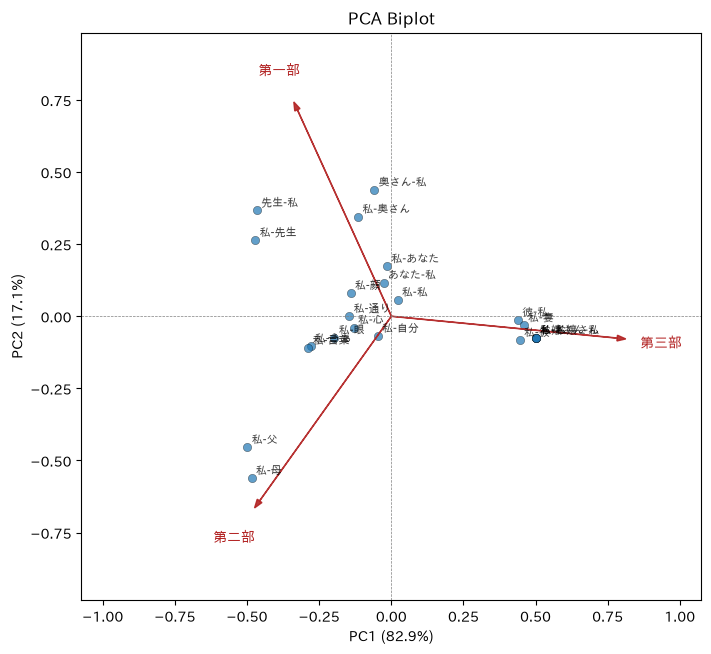

In [84]:
mat = deepcopy(res)
mat = mat[mat.sum(axis=1) > 50]
mat.columns = '第一部', '第二部', '第三部'
mat_t = mat.T
ratio = mat / mat.sum(axis=0)
ratio_t = ratio.T
cl.pca_biplot((ratio_t / ratio.sum(axis=1)).T, scale=False, annotate_points=True)

In [85]:
counted = pd.Series(
    Counter(sum(kokoro_sentence['content'].apply(tokenizer.get_cooc, pos=['名詞', '形容詞'], with_pos=True, stopwords=stopwords), [])))

In [86]:
targets = set(['私', 'Ｋ','お嬢さん'])

def extract(string):
    w1, w2 = string.split('-')
    return w1.split('/')[0], w2.split('/')[0], f'{w1.split("/")[1]}-{w2.split("/")[1]}'

counted_ = [(extract(i), x) for i, x in counted.items()]

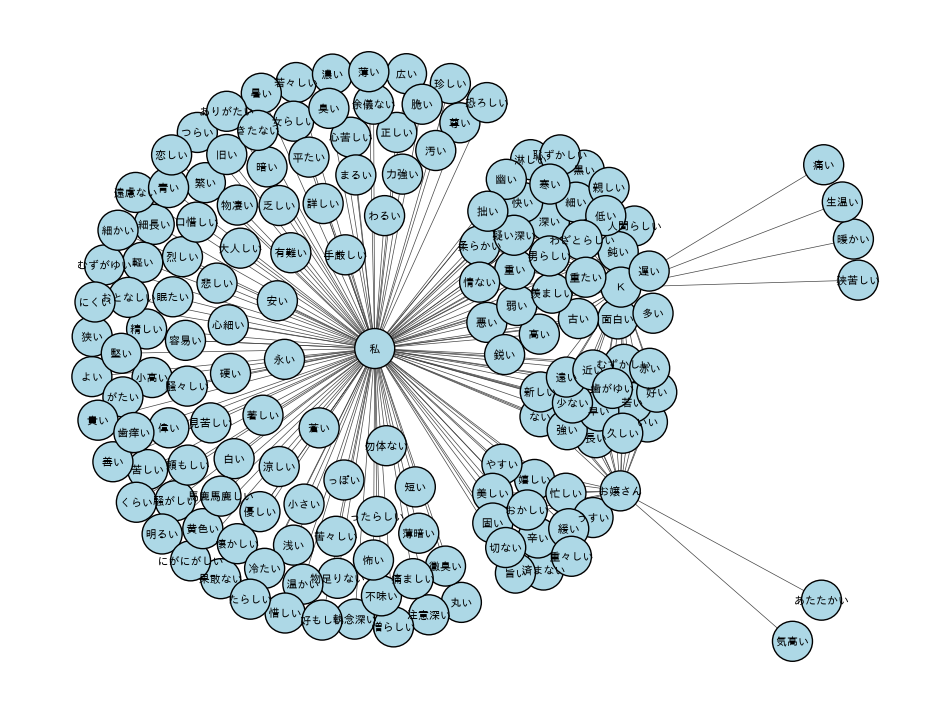

In [87]:
net = pd.DataFrame([
     (i[0], i[1], x) for i, x in counted_
    if ((i[0] in targets) or (i[1] in targets)) and (re.search('形容', i[2]))
    ])
net.columns = 'N1', 'N2', 'freq'
net = net[net['freq'] > 0]
plot_graph(net, stopwords, digraph=False)